# Be²⁺ and BeCl₂ in water — force-field comparison

Direct comparison of Be²⁺ (aq) and BeCl₂ (aq) across two force fields.
A pure water trajectory will be added as a structural reference once available.

| System | Force field | Frames | Atoms |
|---|---|---|---|
| Be²⁺ | MACE-MP-0 | 10 001 | 337 (Be + 112 H₂O) |
| BeCl₂ | MACE-MP-0 | 10 001 | 339 (BeCl₂ + 112 H₂O) |
| Be²⁺ | MACE-POLAR-1-M | 10 001 | 337 |
| BeCl₂ | MACE-POLAR-1-M | 10 001 | 339 |
| pure H₂O | — | *TODO* | *to be added* |

**Colour:** Be²⁺ = blue, BeCl₂ = red, pure water = grey.  
**Line style:** MACE-MP-0 = solid, MACE-POLAR-1-M = dashed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 12})

DATA = Path('../data')

# ── Pure-water reference availability ─────────────────────────────────────────
# Set to True once a pure-water trajectory is available under TRAJS[('H2O', ...)].
# All cells that use this reference are gated on this flag.
PURE_WATER_AVAILABLE = False   # TODO: set True when 40_water (or other) is added <<<<--------------------------------------------------------------------

# ── Trajectory paths ──────────────────────────────────────────────────────────
TRAJS = {
    ('Be2+',  'MP0'):   DATA / 'MACE-MP-0/112_water/Be2+/112_water_Be.traj',
    ('BeCl2', 'MP0'):   DATA / 'MACE-MP-0/112_water/BeCl2/112_water_BeCl2.traj',
    ('Be2+',  'POLAR'): DATA / 'MACE-POLAR-1-M/112_water_Be/Be2+/112_water_Be_polar.traj',
    ('BeCl2', 'POLAR'): DATA / 'MACE-POLAR-1-M/112_water_Be/BeCl2/112_water_BeCl2_polar.traj',
    # ('H2O', 'MP0'): DATA / 'MACE-MP-0/40_water/40_water.traj',  # TODO: add path
}

LOGS = {
    ('Be2+',  'MP0'):   DATA / 'MACE-MP-0/112_water/Be2+/112_water_Be.log',
    ('BeCl2', 'MP0'):   DATA / 'MACE-MP-0/112_water/BeCl2/112_water_BeCl2.log',
    ('Be2+',  'POLAR'): DATA / 'MACE-POLAR-1-M/112_water_Be/Be2+/112_water_Be_polar.log',
    ('BeCl2', 'POLAR'): DATA / 'MACE-POLAR-1-M/112_water_Be/BeCl2/112_water_BeCl2_polar.log',
    # ('H2O', 'MP0'): DATA / 'MACE-MP-0/40_water/40_water.log',   # TODO: add path
}

TRAVIS = {
    ('Be2+',  'MP0'):   DATA / 'MACE-MP-0/112_water/Be2+/travis/',
    ('BeCl2', 'MP0'):   DATA / 'MACE-MP-0/112_water/BeCl2/travis/',
    ('Be2+',  'POLAR'): DATA / 'MACE-POLAR-1-M/112_water_Be/Be2+/travis/',
    ('BeCl2', 'POLAR'): DATA / 'MACE-POLAR-1-M/112_water_Be/BeCl2/travis/',
}

# ── Visual identity ────────────────────────────────────────────────────────────
C  = {'Be2+': 'steelblue', 'BeCl2': 'tomato', 'H2O': '0.45'}
LS = {'MP0': '-', 'POLAR': '--'}
LW = 1.5

LABELS = {
    ('Be2+',  'MP0'):   r'Be$^{2+}$ MACE-MP-0',
    ('BeCl2', 'MP0'):   r'BeCl$_2$ MACE-MP-0',
    ('Be2+',  'POLAR'): r'Be$^{2+}$ MACE-POLAR-1-M',
    ('BeCl2', 'POLAR'): r'BeCl$_2$ MACE-POLAR-1-M',
    ('H2O',   'MP0'):   r'Pure H$_2$O (MACE-MP-0)',
}
FF_LABELS = {'MP0': 'MACE-MP-0', 'POLAR': 'MACE-POLAR-1-M'}

# 10 sub-sampled timesteps × 0.5 fs = 5 fs/frame
dt_per_frame = 10 * 0.5e-3   # ps

def load_travis(key, fname):
    """Load a Travis RDF CSV. Returns (r_Å, g, cumulative_integral) arrays."""
    path = TRAVIS[key] / fname
    df = pd.read_csv(path, sep=';')
    df.columns = df.columns.str.strip()
    r = df.iloc[:, 0].values / 100   # pm → Å
    g = df.iloc[:, 1].values
    n = df.iloc[:, 2].values
    return r, g, n

print(f'Setup complete.  PURE_WATER_AVAILABLE = {PURE_WATER_AVAILABLE}')
print('Trajectory files:')
for k, p in TRAJS.items():
    print(f'  {k}: {"found" if p.exists() else "MISSING"}')

Setup complete.  PURE_WATER_AVAILABLE = False
Trajectory files:
  ('Be2+', 'MP0'): found
  ('BeCl2', 'MP0'): found
  ('Be2+', 'POLAR'): found
  ('BeCl2', 'POLAR'): found


---
## 1 — Solvation structure (Travis RDFs)

Pre-computed RDFs from TRAVIS — same analysis as `beryllium.ipynb`, included here
for validation and comparison across all four systems on a single set of axes.
Semicolon-separated CSV files; distances in pm, converted to Å.

### 1a — Be–O first-shell coordination

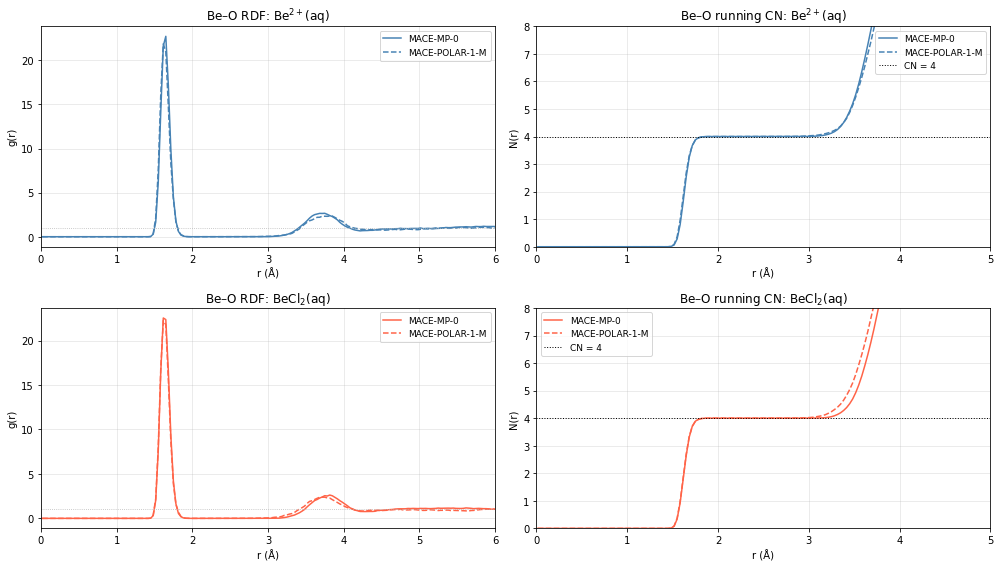

System                                Peak (Å)   1st-shell CN
-------------------------------------------------------------
  Be$^{2+}$ MACE-MP-0                     1.65           4.00
  Be$^{2+}$ MACE-POLAR-1-M                1.62           4.00
  BeCl$_2$ MACE-MP-0                      1.62           4.00
  BeCl$_2$ MACE-POLAR-1-M                 1.62           4.00


In [2]:
sys_titles = {
    'Be2+':  r'Be$^{2+}$(aq)',
    'BeCl2': r'BeCl$_2$(aq)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, sys in enumerate(('Be2+', 'BeCl2')):
    for ff in ('MP0', 'POLAR'):
        r, g, n = load_travis((sys, ff), 'rdf_Be_O_[Be1r_O1o].csv')
        axes[row, 0].plot(r, g, color=C[sys], ls=LS[ff], lw=LW, label=FF_LABELS[ff])
        axes[row, 1].plot(r, n, color=C[sys], ls=LS[ff], lw=LW, label=FF_LABELS[ff])

    axes[row, 0].axhline(1, color='0.7', lw=0.8, ls=':')
    axes[row, 0].set_xlim(0, 6); axes[row, 0].set_xlabel('r (Å)'); axes[row, 0].set_ylabel('g(r)')
    axes[row, 0].set_title(f'Be\u2013O RDF: {sys_titles[sys]}')
    axes[row, 0].legend(fontsize=9)

    axes[row, 1].axhline(4, color='k', lw=1, ls=':', label='CN = 4')
    axes[row, 1].set_xlim(0, 5); axes[row, 1].set_ylim(0, 8)
    axes[row, 1].set_xlabel('r (Å)'); axes[row, 1].set_ylabel('N(r)')
    axes[row, 1].set_title(f'Be\u2013O running CN: {sys_titles[sys]}')
    axes[row, 1].legend(fontsize=9)

plt.tight_layout(); plt.show()

print(f'{"System":<35} {"Peak (Å)":>10} {"1st-shell CN":>14}')
print('-' * 61)
for sys in ('Be2+', 'BeCl2'):
    for ff in ('MP0', 'POLAR'):
        r, g, n = load_travis((sys, ff), 'rdf_Be_O_[Be1r_O1o].csv')
        pk_i = int(np.argmax(g))
        mn_i = pk_i + int(g[pk_i:pk_i + 30].argmin())
        print(f'  {LABELS[(sys, ff)]:<33} {r[pk_i]:>10.2f} {n[mn_i]:>14.2f}')

### 1b — Second solvation shell: Be[O]–O

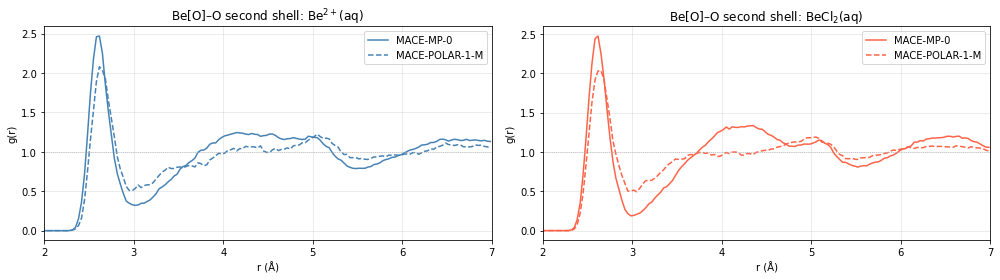

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sys_titles = {
    'Be2+':  r'Be$^{2+}$(aq)',
    'BeCl2': r'BeCl$_2$(aq)',
}
for i, sys in enumerate(('Be2+', 'BeCl2')):
    for ff in ('MP0', 'POLAR'):
        r, g, _ = load_travis((sys, ff), 'rdf_BeH8O4_H2O_[Or_Oo].csv')
        axes[i].plot(r, g, color=C[sys], ls=LS[ff], lw=LW, label=FF_LABELS[ff])
    axes[i].axhline(1, color='0.7', lw=0.8, ls=':')
    axes[i].set_xlim(2, 7); axes[i].set_xlabel('r (Å)'); axes[i].set_ylabel('g(r)')
    axes[i].set_title(f'Be[O]–O second shell: {sys_titles[sys]}')
    axes[i].legend()

plt.tight_layout(); plt.show()

### 1c — H₂O–H₂O O–O in ionic solutions

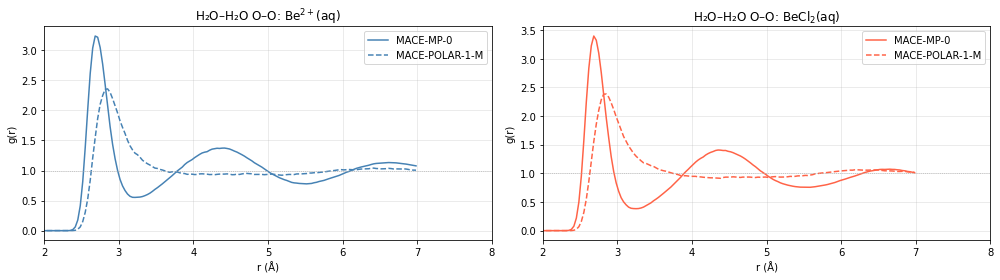

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, sys in enumerate(('Be2+', 'BeCl2')):
    for ff in ('MP0', 'POLAR'):
        r, g, _ = load_travis((sys, ff), 'rdf_H2O_H2O_[Or_Oo].csv')
        axes[i].plot(r, g, color=C[sys], ls=LS[ff], lw=LW, label=FF_LABELS[ff])
    axes[i].axhline(1, color='0.7', lw=0.8, ls=':')
    axes[i].set_xlim(2, 8); axes[i].set_xlabel('r (Å)'); axes[i].set_ylabel('g(r)')
    axes[i].set_title(f'H₂O–H₂O O–O: {sys_titles[sys]}')
    axes[i].legend()

plt.tight_layout(); plt.show()

### 1d — Be–Cl association (BeCl₂ only)

MACE-MP-0 shows no Be–Cl correlation beyond ~2.5 Å, implying complete dissociation;
MACE-POLAR-1-M retains a first-shell Be–Cl peak, indicating partial association.
Long-range cutoff RDF used so the full solution structure is visible.

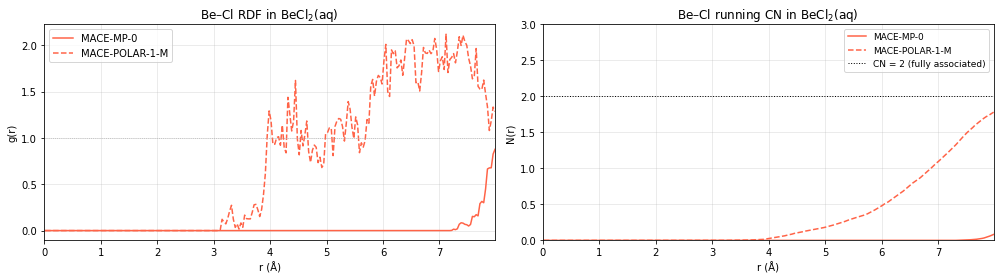

MACE-MP-0             : peak 7.98 Å   CN(first shell) = 0.08
MACE-POLAR-1-M        : peak 7.12 Å   CN(first shell) = 1.73


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ff in ('MP0', 'POLAR'):
    r, g, n = load_travis(('BeCl2', ff), 'rdf_Be_Cl_[Be1r_Cl1o]_long.csv')
    axes[0].plot(r, g, color=C['BeCl2'], ls=LS[ff], lw=LW, label=FF_LABELS[ff])
    axes[1].plot(r, n, color=C['BeCl2'], ls=LS[ff], lw=LW, label=FF_LABELS[ff])

axes[0].axhline(1, color='0.7', lw=0.8, ls=':')
axes[0].set_xlim(0, max(r)); axes[0].set_xlabel('r (Å)'); axes[0].set_ylabel('g(r)')
axes[0].set_title(r'Be–Cl RDF in BeCl$_2$(aq)')
axes[0].legend()

axes[1].axhline(2, color='k', lw=1, ls=':', label='CN = 2 (fully associated)')
axes[1].set_xlim(0, max(r)); axes[1].set_ylim(0, 3)
axes[1].set_xlabel('r (Å)'); axes[1].set_ylabel('N(r)')
axes[1].set_title(r'Be–Cl running CN in BeCl$_2$(aq)')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

for ff in ('MP0', 'POLAR'):
    r, g, n = load_travis(('BeCl2', ff), 'rdf_Be_Cl_[Be1r_Cl1o]_long.csv')
    pk_i = int(np.argmax(g))
    mn_i = pk_i + int(g[pk_i:pk_i + 30].argmin())
    print(f'{FF_LABELS[ff]:<22}: peak {r[pk_i]:.2f} Å   CN(first shell) = {n[mn_i]:.2f}')

---
## 2 — O–O RDF: pure water vs ionic solutions

The O–O radial distribution function captures the bulk water structure.
A pure water trajectory (MACE-MP-0) will serve as the structural reference once
added. To enable this section:
1. Uncomment `('H2O', 'MP0')` entries in `TRAJS` and `LOGS` in the setup cell.
2. Set `PURE_WATER_AVAILABLE = True` in the setup cell.

Until then this section plots only the ionic solutions for comparison.

In [6]:
from chempiler import ChempilerTrajectory

# ── Pure water O–O RDF ────────────────────────────────────────────────────────
# Requires PURE_WATER_AVAILABLE = True and path in TRAJS[('H2O', 'MP0')].
if PURE_WATER_AVAILABLE:
    traj_w = ChempilerTrajectory(str(TRAJS[('H2O', 'MP0')]), mode='molecular',
                                 covalent_scale=1.0)
    traj_w.build(cache_file='tests/be_w_cache.h5')
    r_oo_w, g_oo_w = traj_w.rdf(center={'H2O': 'O'}, target={'H2O': 'O'},
                                  rmax=6.0, dr=0.05, n_workers=2)
    print('Pure water O–O RDF computed.')
else:
    traj_w = None
    r_oo_w = g_oo_w = None
    print('[placeholder] Pure water trajectory not yet available.')

[placeholder] Pure water trajectory not yet available.


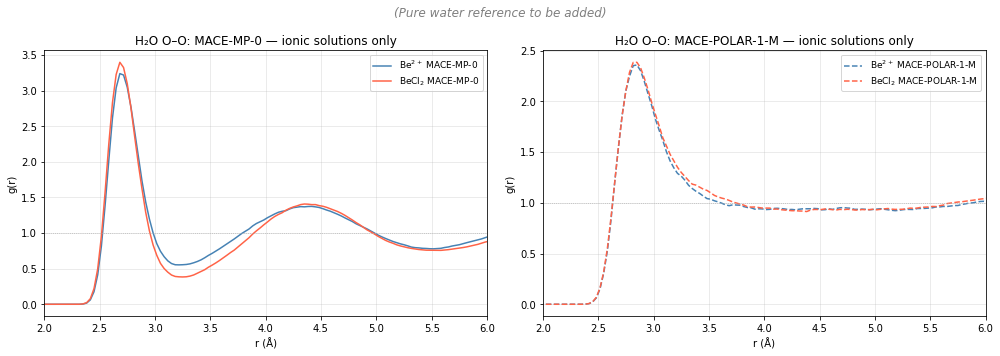

In [7]:
if not PURE_WATER_AVAILABLE:
    # Ionic solutions only until pure water reference is added
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for i, ff in enumerate(('MP0', 'POLAR')):
        for sys in ('Be2+', 'BeCl2'):
            r, g, _ = load_travis((sys, ff), 'rdf_H2O_H2O_[Or_Oo].csv')
            axes[i].plot(r, g, color=C[sys], ls=LS[ff], lw=LW, label=LABELS[(sys, ff)])
        axes[i].axhline(1, color='0.7', lw=0.8, ls=':')
        axes[i].set_xlim(2, 6); axes[i].set_xlabel('r (Å)'); axes[i].set_ylabel('g(r)')
        axes[i].set_title(f'H₂O O–O: {FF_LABELS[ff]} — ionic solutions only')
        axes[i].legend(fontsize=9)
    plt.suptitle('(Pure water reference to be added)', color='0.5', style='italic')
    plt.tight_layout(); plt.show()
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Left: MACE-MP-0
    axes[0].plot(r_oo_w, g_oo_w, color=C['H2O'], lw=2, ls='-',
                 label=LABELS[('H2O', 'MP0')], zorder=3)
    for sys in ('Be2+', 'BeCl2'):
        r, g, _ = load_travis((sys, 'MP0'), 'rdf_H2O_H2O_[Or_Oo].csv')
        axes[0].plot(r, g, color=C[sys], ls='-', lw=LW, label=LABELS[(sys, 'MP0')])
    axes[0].axhline(1, color='0.7', lw=0.8, ls=':')
    axes[0].set_xlim(2, 6); axes[0].set_xlabel('r (Å)'); axes[0].set_ylabel('g(r)')
    axes[0].set_title('H₂O O–O: MACE-MP-0'); axes[0].legend(fontsize=9)
    # Right: MACE-POLAR-1-M
    axes[1].plot(r_oo_w, g_oo_w, color=C['H2O'], lw=2, ls='-',
                 label=LABELS[('H2O', 'MP0')] + ' (ref)', zorder=3)
    for sys in ('Be2+', 'BeCl2'):
        r, g, _ = load_travis((sys, 'POLAR'), 'rdf_H2O_H2O_[Or_Oo].csv')
        axes[1].plot(r, g, color=C[sys], ls='--', lw=LW, label=LABELS[(sys, 'POLAR')])
    axes[1].axhline(1, color='0.7', lw=0.8, ls=':')
    axes[1].set_xlim(2, 6); axes[1].set_xlabel('r (Å)'); axes[1].set_ylabel('g(r)')
    axes[1].set_title('H₂O O–O: MACE-POLAR-1-M'); axes[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()

---
## 3 — Species composition & Be coordination

Molecular formulas resolved by chempiler (covalent_scale=1.0; Be–O cutoff ≈ 1.92 Å
with ASE neighbour-list skin, comfortably above the ~1.63 Å Be–O bond).
Expected:
- **Be²⁺ system:** primarily `BeH8O4` = [Be(H₂O)₄]²⁺ tetrahedron.
- **BeCl₂ system:** `BeH8O4` if Cl fully dissociates; `BeClH6O3` / `BeCl2H4O2`
  if Cl stays associated (consistent with Be–Cl RDF above).

In [8]:
# Load all four Be trajectories (cache files keep re-runs fast)
trajs = {}
cache_names = {
    ('Be2+',  'MP0'):   'tests/be_mp0_ion_cache.h5',
    ('BeCl2', 'MP0'):   'tests/be_mp0_cl_cache.h5',
    ('Be2+',  'POLAR'): 'tests/be_pol_ion_cache.h5',
    ('BeCl2', 'POLAR'): 'tests/be_pol_cl_cache.h5',
}
for key, path in TRAJS.items():
    if key[0] == 'H2O':
        continue
    print(f'Loading {key} ...', end=' ', flush=True)
    t = ChempilerTrajectory(str(path), mode='molecular', covalent_scale=1.0)
    t.build(cache_file=cache_names[key])
    trajs[key] = t
    print('done.')

Loading ('Be2+', 'MP0') ... [Chempiler] loaded cache → tests/be_mp0_ion_cache.h5
done.
Loading ('BeCl2', 'MP0') ... [Chempiler] loaded cache → tests/be_mp0_cl_cache.h5
done.
Loading ('Be2+', 'POLAR') ... [Chempiler] loaded cache → tests/be_pol_ion_cache.h5
done.
Loading ('BeCl2', 'POLAR') ... [Chempiler] loaded cache → tests/be_pol_cl_cache.h5
done.


In [9]:
# Print species composition across all four systems
from collections import Counter

all_forms = set()
summaries = {}
for key, t in trajs.items():
    s = t.summary()
    summaries[key] = s
    all_forms |= set(s)

# Sort: most-abundant first (by total count across all systems)
all_forms = sorted(all_forms,
    key=lambda f: -sum(summaries[k].get(f, 0) for k in trajs))

header = f'{"Formula":<16}' + ''.join(f'{LABELS[k]:>28}' for k in trajs)
print(header)
print('-' * len(header))
for f in all_forms:
    row = f'  {f:<14}'
    for key, t in trajs.items():
        avg = summaries[key].get(f, 0) / len(t.frames)
        row += f'{avg:>28.4f}'
    print(row)

Formula                  Be$^{2+}$ MACE-MP-0          BeCl$_2$ MACE-MP-0    Be$^{2+}$ MACE-POLAR-1-M     BeCl$_2$ MACE-POLAR-1-M
--------------------------------------------------------------------------------------------------------------------------------
  H2O                                83.5721                     79.9380                    104.6688                    104.5114
  H4O2                                7.6570                      8.4678                      1.0172                      1.0032
  Cl                                  0.0000                      1.7823                      0.0000                      1.9387
  H6O3                                1.3639                      1.7296                      0.0226                      0.0248
  BeH10O5                             0.1308                      0.1570                      0.4009                      0.3826
  BeH12O6                             0.2208                      0.2379                      0.2

---
## 4 — Self-diffusion (MSD)

Mean squared displacement via the Einstein relation MSD(τ) = 6Dτ.
5 fs/frame → conversion factor 0.02 cm²/s per Å²/frame.

Quantities computed:
- **D(H₂O)** — how strongly does the solute retard water mobility?
- **D(Be complex)** — mobility of the Be-containing molecular species.

In [10]:
import warnings

_conv = 1e-16 / 5e-15   # Å²/frame → cm²/s  (5 fs/frame)

# H₂O MSD — all four Be systems
msd_h2o = {}
D_h2o   = {}
for key, t in trajs.items():
    lags, msd, _ = t.msd('H2O', max_lag=200)
    msd_h2o[key] = (lags, msd)
    _m = lags > lags[-1] * 2 // 3
    D_h2o[key] = np.polyfit(lags[_m], msd[_m], 1)[0] / 6 * _conv

# Pure water H₂O MSD (placeholder — only runs if PURE_WATER_AVAILABLE)
lags_w = msd_w = D_h2o_ref = None
if PURE_WATER_AVAILABLE:
    lags_w, msd_w, _ = traj_w.msd('H2O', max_lag=400)
    _m = lags_w > lags_w[-1] * 2 // 3
    D_h2o_ref = np.polyfit(lags_w[_m], msd_w[_m], 1)[0] / 6 * _conv

# Be complex MSD — determine formula from summary
msd_be  = {}
D_be    = {}
Be_form = {}
for key, t in trajs.items():
    be_forms = {f: c for f, c in summaries[key].items() if 'Be' in f}
    if not be_forms:
        continue
    formula = max(be_forms, key=be_forms.get)
    Be_form[key] = formula
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        lags, msd, _ = t.msd(formula, max_lag=200)
    msd_be[key]  = (lags, msd)
    _v = ~np.isnan(msd)
    if _v.sum() > 10:
        _m = lags[_v] > lags[_v][-1] * 2 // 3
        D_be[key] = np.polyfit(lags[_v][_m], msd[_v][_m], 1)[0] / 6 * _conv

print('MSD computed.')
print(f'Be complex formulas: {Be_form}')

MSD computed.
Be complex formulas: {('Be2+', 'MP0'): 'BeH14O7', ('BeCl2', 'MP0'): 'BeH12O6', ('Be2+', 'POLAR'): 'BeH10O5', ('BeCl2', 'POLAR'): 'BeH10O5'}


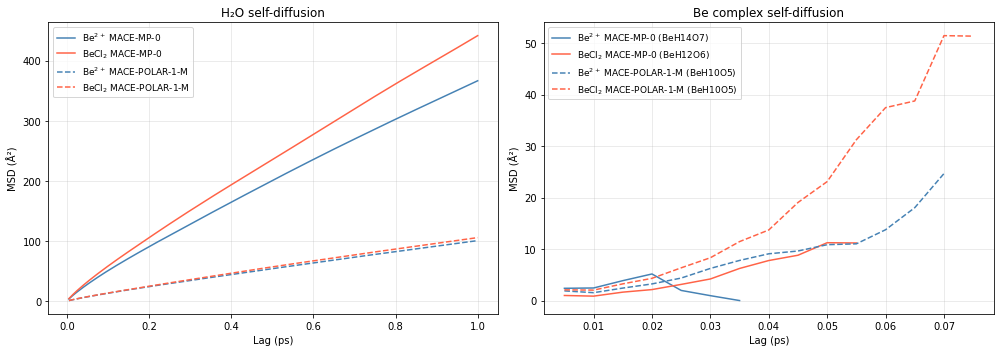

System                                D(H₂O) (cm²/s)    D(Be) (cm²/s)
---------------------------------------------------------------------
  Be$^{2+}$ MACE-MP-0                     5.3968e-03                —
  BeCl$_2$ MACE-MP-0                      6.7650e-03       4.2165e-03
  Be$^{2+}$ MACE-POLAR-1-M                1.5306e-03       1.1537e-02
  BeCl$_2$ MACE-POLAR-1-M                 1.5958e-03       1.8055e-02


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: H₂O MSD ─────────────────────────────────────────────────────────────
if PURE_WATER_AVAILABLE:
    axes[0].plot(lags_w * dt_per_frame, msd_w, color=C['H2O'], lw=2, ls='-',
                 label=LABELS[('H2O', 'MP0')])
for key, (lags, msd) in msd_h2o.items():
    axes[0].plot(lags * dt_per_frame, msd, color=C[key[0]], ls=LS[key[1]], lw=LW,
                 label=LABELS[key])
axes[0].set_xlabel('Lag (ps)'); axes[0].set_ylabel('MSD (Å²)')
axes[0].set_title('H₂O self-diffusion')
axes[0].legend(fontsize=9)

# ── Right: Be complex MSD ──────────────────────────────────────────────────────
for key, (lags, msd) in msd_be.items():
    _v = ~np.isnan(msd)
    axes[1].plot(lags[_v] * dt_per_frame, msd[_v], color=C[key[0]], ls=LS[key[1]],
                 lw=LW, label=f'{LABELS[key]} ({Be_form[key]})')
axes[1].set_xlabel('Lag (ps)'); axes[1].set_ylabel('MSD (Å²)')
axes[1].set_title('Be complex self-diffusion')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

# ── D table ───────────────────────────────────────────────────────────────────
print(f'{"System":<35} {"D(H₂O) (cm²/s)":>16} {"D(Be) (cm²/s)":>16}')
print('-' * 69)
if PURE_WATER_AVAILABLE:
    print(f'  {LABELS[("H2O","MP0")]:<33} {D_h2o_ref:>16.4e} {"—":>16}')
for key in trajs:
    d_be = f'{D_be[key]:.4e}' if key in D_be else '—'
    print(f'  {LABELS[key]:<33} {D_h2o[key]:>16.4e} {d_be:>16}')

---
## 5 — Vibrational dynamics (VACF & power spectrum)

Total-system velocity autocorrelation function (VACF) from the `.log` files,
at full 0.5 fs resolution (100 001 steps = 50 ps for Be systems).
A pure water log will be added as reference once available (`PURE_WATER_AVAILABLE`).

- **Green–Kubo D:** D = (1/3) ∫ C(t) dt; unit conversion 1 Å²/fs = 0.1 cm²/s.
  Cross-checks D(H₂O) from MSD. VACF is dominated by H₂O (Be is heavy, slow).
- **VDOS:** FFT of truncated (2 ps), half-cosine-windowed VACF.
  The tightly bound Be²⁺ first shell is expected to blue-shift the libration band
  and redshift the O–H stretch of coordinated waters.

In [12]:
# Load Be system log files
vacfs = {}
dt_vacf = 0.5   # fs per step

for key, logpath in LOGS.items():
    print(f'Loading VACF {key} ...', end=' ', flush=True)
    v = np.loadtxt(str(logpath), skiprows=1, usecols=8)
    vacfs[key] = v
    print(f'{len(v)} steps  VACF(0)={v[0]:.5f} Å²/fs²')

# Common time axis for Be systems (50 ps)
t_vacf = np.arange(len(vacfs[('Be2+', 'MP0')])) * dt_vacf

# Pure water time axis — only defined if available
if PURE_WATER_AVAILABLE and ('H2O', 'MP0') in vacfs:
    t_vacf_w = np.arange(len(vacfs[('H2O', 'MP0')])) * dt_vacf
else:
    t_vacf_w = None

Loading VACF ('Be2+', 'MP0') ... 100001 steps  VACF(0)=0.05698 Å²/fs²
Loading VACF ('BeCl2', 'MP0') ... 100001 steps  VACF(0)=0.06007 Å²/fs²
Loading VACF ('Be2+', 'POLAR') ... 100001 steps  VACF(0)=0.05725 Å²/fs²
Loading VACF ('BeCl2', 'POLAR') ... 100001 steps  VACF(0)=0.06233 Å²/fs²


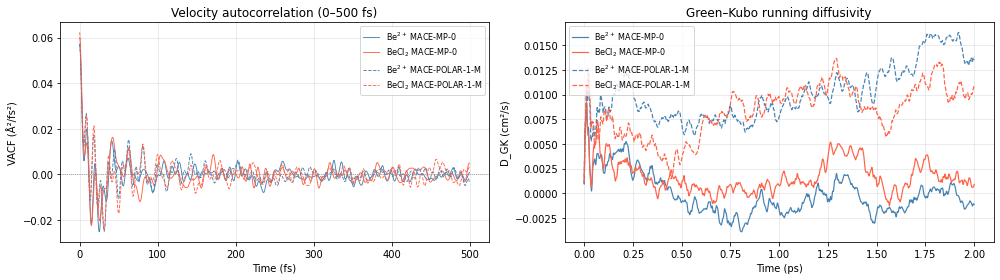

System                                  D_GK (cm²/s)       D(H₂O) MSD
---------------------------------------------------------------------
  Be$^{2+}$ MACE-MP-0                     8.8042e-03       5.3968e-03
  BeCl$_2$ MACE-MP-0                      2.2629e-03       6.7650e-03
  Be$^{2+}$ MACE-POLAR-1-M                1.0758e-02       1.5306e-03
  BeCl$_2$ MACE-POLAR-1-M                 3.2337e-02       1.5958e-03


In [13]:
# VACF plots (0–500 fs) and running Green–Kubo diffusivity (0–2 ps)
N_PLOT = int(500  / dt_vacf)
N_GK   = int(2000 / dt_vacf)

# Compute running D_GK for all available systems
D_gk = {}
for key, v in vacfs.items():
    running = np.cumsum(v) * dt_vacf / 3 * 0.1   # cm²/s
    D_gk[key] = (running, float(running[-1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: VACF decay (0–500 fs)
for key, v in vacfs.items():
    sys, ff = key
    col = C[sys]
    ls  = LS[ff] if sys != 'H2O' else '-'
    axes[0].plot(t_vacf[:N_PLOT], v[:N_PLOT], color=col, ls=ls,
                 lw=0.9, label=LABELS[key])
axes[0].axhline(0, color='0.5', lw=0.8, ls=':')
axes[0].set_xlabel('Time (fs)'); axes[0].set_ylabel('VACF (Å²/fs²)')
axes[0].set_title('Velocity autocorrelation (0–500 fs)')
axes[0].legend(fontsize=8)

# Right: running D_GK (0–2 ps)
for key, (running, _) in D_gk.items():
    sys, ff = key
    t_ax = (t_vacf_w if (sys == 'H2O' and t_vacf_w is not None) else t_vacf)[:N_GK] / 1000
    axes[1].plot(t_ax, running[:N_GK], color=C[sys],
                 ls=LS[ff] if sys != 'H2O' else '-', lw=1.2, label=LABELS[key])
axes[1].set_xlabel('Time (ps)'); axes[1].set_ylabel('D_GK (cm²/s)')
axes[1].set_title('Green–Kubo running diffusivity')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f'{"System":<35} {"D_GK (cm²/s)":>16} {"D(H₂O) MSD":>16}')
print('-' * 69)
if PURE_WATER_AVAILABLE and ("H2O", "MP0") in D_gk:
    gk_ref = D_gk[("H2O", "MP0")][1]
    print(f'  {LABELS[("H2O","MP0")]:<33} {gk_ref:>16.4e} {D_h2o_ref:>16.4e}')
for key in trajs:
    print(f'  {LABELS[key]:<33} {D_gk[key][1]:>16.4e} {D_h2o[key]:>16.4e}')

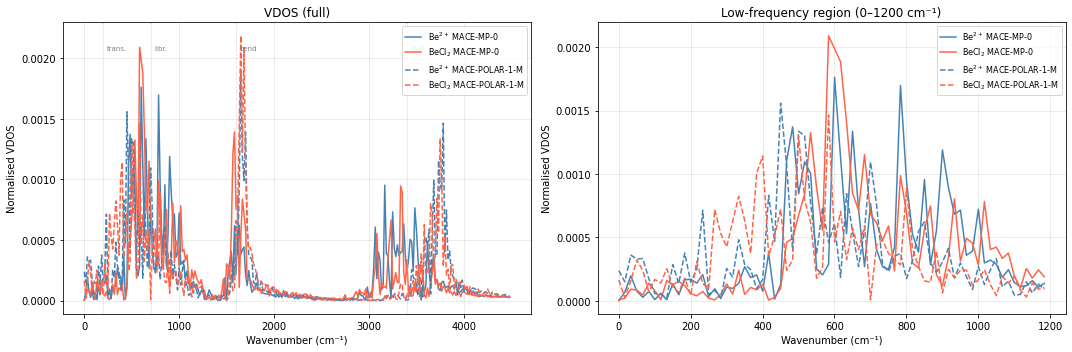

System                                Libration (cm⁻¹)   HOH bend   O–H str.
---------------------------------------------------------------------------
  Be$^{2+}$ MACE-MP-0                              600       1634       3169
  BeCl$_2$ MACE-MP-0                               584       1584       3336
  Be$^{2+}$ MACE-POLAR-1-M                         450       1651       3786
  BeCl$_2$ MACE-POLAR-1-M                          584       1651       3753


In [14]:
# Vibrational density of states (VDOS) via FFT of windowed VACF
TRUNC_FS = 2000
n_trunc  = int(TRUNC_FS / dt_vacf)
window   = 0.5 * (1 + np.cos(np.pi * np.arange(n_trunc) / n_trunc))  # half-cosine

vdos = {}
for key, v in vacfs.items():
    s = np.abs(np.fft.rfft(v[:n_trunc] * window))**2
    s /= np.trapz(s, np.fft.rfftfreq(n_trunc, d=dt_vacf) * 33356)
    vdos[key] = s

freqs_cm1 = np.fft.rfftfreq(n_trunc, d=dt_vacf) * 33356   # cm⁻¹

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

mask_full = freqs_cm1 <= 4500
mask_lo   = freqs_cm1 <= 1200

for key, s in vdos.items():
    sys, ff = key
    col = C[sys]
    ls  = LS[ff] if sys != 'H2O' else '-'
    lw  = 2.0 if sys == 'H2O' else LW
    axes[0].plot(freqs_cm1[mask_full], s[mask_full], color=col, ls=ls,
                 lw=lw, label=LABELS[key])
    axes[1].plot(freqs_cm1[mask_lo], s[mask_lo], color=col, ls=ls,
                 lw=lw, label=LABELS[key])

for ax, title in zip(axes, ['VDOS (full)', 'Low-frequency region (0–1200 cm⁻¹)']):
    ax.set_xlabel('Wavenumber (cm⁻¹)'); ax.set_ylabel('Normalised VDOS')
    ax.set_title(title)
    ax.legend(fontsize=8)
for nu, lbl in [(200, 'trans.'), (700, 'libr.'), (1600, 'bend'), (3400, 'O–H')]:
    if nu <= 4500:
        axes[0].axvline(nu, color='0.75', lw=0.8, ls=':')
        axes[0].text(nu + 40, axes[0].get_ylim()[1] * 0.9, lbl, fontsize=7, color='0.5')

plt.tight_layout(); plt.show()

print(f'{"System":<35} {"Libration (cm⁻¹)":>18} {"HOH bend":>10} {"O–H str.":>10}')
print('-' * 75)
for key, s in vdos.items():
    peaks = []
    for lo, hi in [(300, 1000), (1200, 2000), (2800, 4000)]:
        m = (freqs_cm1 >= lo) & (freqs_cm1 <= hi)
        peaks.append(f'{freqs_cm1[m][np.argmax(s[m])]:6.0f}')
    print(f'  {LABELS[key]:<33} {peaks[0]:>18} {peaks[1]:>10} {peaks[2]:>10}')